<a href="https://colab.research.google.com/github/emiliomartineziteso/sim-mat/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Resumen por semana ===
 Semana  Demanda  Staff  Horas_reg   OT  Contratistas  Contrataciones  Despidos  Costo_staff_sem  Costo_total_sem
      1      750  18.75      750.0  0.0           0.0            0.00      1.25          11250.0          11437.5
      2      780  19.50      780.0  0.0           0.0            0.75      0.00          11700.0          11850.0
      3      800  20.00      800.0  0.0           0.0            0.50      0.00          12000.0          12100.0
      4      850  21.25      850.0  0.0           0.0            1.25      0.00          12750.0          13000.0
      5      900  22.50      900.0  0.0           0.0            1.25      0.00          13500.0          13750.0
      6      950  23.75      950.0  0.0           0.0            1.25      0.00          14250.0          14500.0
      7     1000  23.75      950.0 50.0           0.0           -0.00      0.00          14250.0          15375.0
      8      950  23.75      950.0  0.0           0.0       

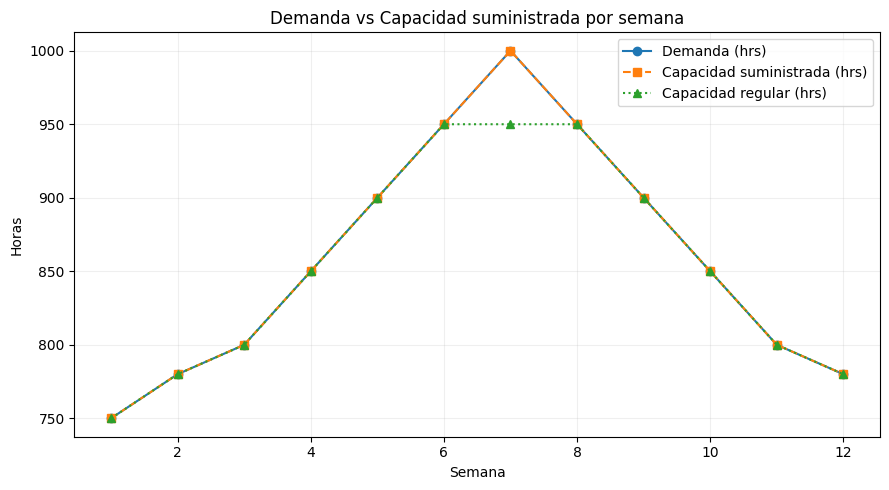

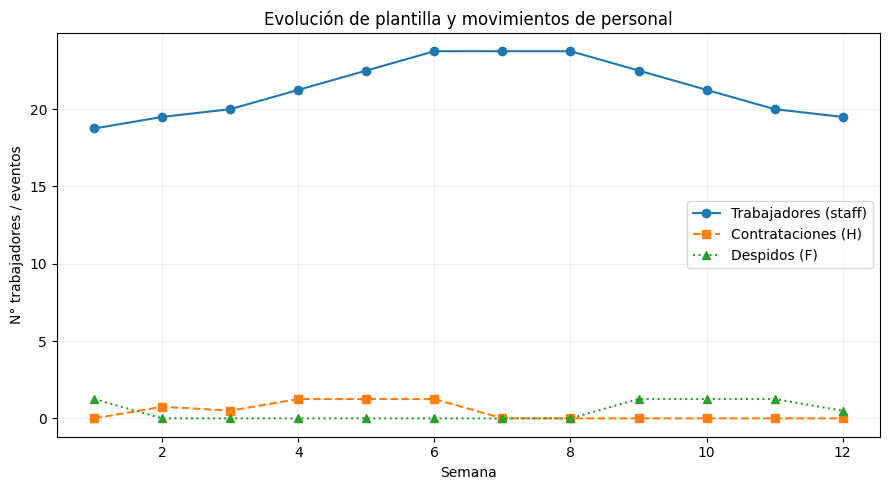

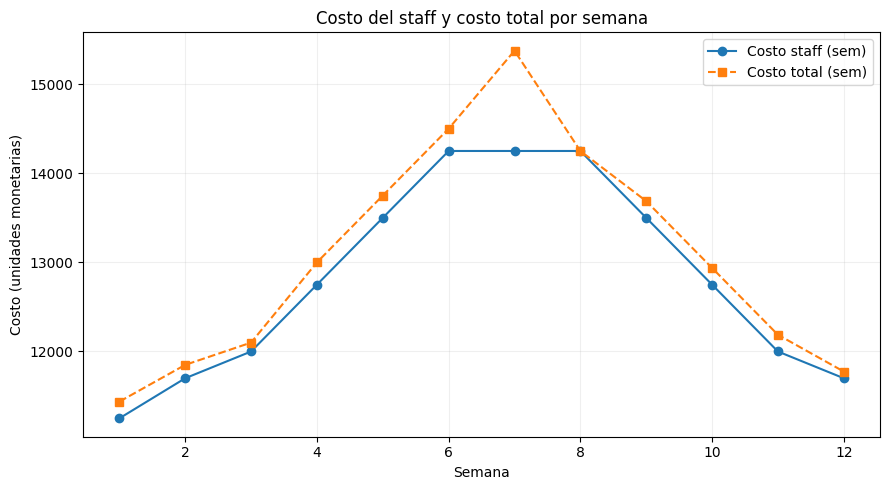

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# ==========================
# PARÁMETROS DEL MODELO
# ==========================
T = 12  # número de semanas
demanda = np.array([750, 780, 800, 850, 900, 950, 1000, 950, 900, 850, 800, 780])

H_std = 40       # horas estándar por trabajador por semana
OT_max = 10      # horas extra máximas por trabajador
salario_hora_reg = 15
salario_hora_ot = 22.5
salario_hora_contratista = 30
costo_contratacion = 200
costo_despido = 150
staff_inicial = 20
C_max = 500      # máx horas de contratistas por semana

# costo semanal fijo por trabajador (40 horas * salario regular)
costo_trab_sem = H_std * salario_hora_reg

# ==========================
# VARIABLES DE DECISIÓN
# ==========================
# Orden de variables por semana: [s_t, ot_t, c_t, h_t, f_t]
n_vars_sem = 5
n_vars = T * n_vars_sem

# ==========================
# FUNCIÓN OBJETIVO
# ==========================
c = np.zeros(n_vars)
for t in range(T):
    base = t * n_vars_sem
    c[base] = costo_trab_sem
    c[base+1] = salario_hora_ot
    c[base+2] = salario_hora_contratista
    c[base+3] = costo_contratacion
    c[base+4] = costo_despido

# ==========================
# RESTRICCIONES
# ==========================
A_eq = []
b_eq = []

# balance staff
for t in range(T):
    row = np.zeros(n_vars)
    base = t * n_vars_sem
    if t == 0:
        row[base] = 1   # s0
        row[base+3] = -1  # h0
        row[base+4] = 1   # f0
        b_eq.append(staff_inicial)
    else:
        prev = (t-1)*n_vars_sem
        row[base] = 1
        row[prev] = -1
        row[base+3] = -1
        row[base+4] = 1
        b_eq.append(0)
    A_eq.append(row)

# demanda
A_ub = []
b_ub = []

for t in range(T):
    row = np.zeros(n_vars)
    base = t * n_vars_sem
    row[base] = -H_std
    row[base+1] = -1
    row[base+2] = -1
    A_ub.append(row)
    b_ub.append(-demanda[t])

# límite OT por trabajador
for t in range(T):
    row = np.zeros(n_vars)
    base = t * n_vars_sem
    row[base+1] = 1
    row[base] = -OT_max
    A_ub.append(row)
    b_ub.append(0)

# límite contratistas
for t in range(T):
    row = np.zeros(n_vars)
    base = t * n_vars_sem
    row[base+2] = 1
    A_ub.append(row)
    b_ub.append(C_max)

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)
A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

# ==========================
# RESOLVER PROBLEMA
# ==========================
bounds = [(0, None)] * n_vars
res = linprog(c, A_ub=A_ub, b_ub=b_ub,
              A_eq=A_eq, b_eq=b_eq,
              bounds=bounds, method="highs")

# ==========================
# PROCESAR RESULTADOS
# ==========================
if res.success:
    x = res.x
    semanas = []
    staff, ot, contr, hires, fires = [], [], [], [], []
    costo_staff, costo_total = [], []

    for t in range(T):
        base = t*n_vars_sem
        s, ot_t, c_t, h_t, f_t = x[base:base+5]
        semanas.append(t+1)
        staff.append(s)
        ot.append(ot_t)
        contr.append(c_t)
        hires.append(h_t)
        fires.append(f_t)
        costo_staff.append(s * costo_trab_sem)
        costo_total.append(s * costo_trab_sem + ot_t*salario_hora_ot +
                           c_t*salario_hora_contratista +
                           h_t*costo_contratacion + f_t*costo_despido)

    df = pd.DataFrame({
        "Semana": semanas,
        "Demanda": demanda,
        "Staff": np.round(staff, 4),
        "Horas_reg": np.round(np.array(staff)*H_std, 4),
        "OT": np.round(ot, 4),
        "Contratistas": np.round(contr, 4),
        "Contrataciones": np.round(hires, 4),
        "Despidos": np.round(fires, 4),
        "Costo_staff_sem": np.round(costo_staff, 2),
        "Costo_total_sem": np.round(costo_total, 2)
    })

    pd.set_option('display.max_columns', None)
    print("\n=== Resumen por semana ===")
    print(df.to_string(index=False))
    print("\nCosto total (función objetivo):", round(res.fun,2))

    # ==========================
    # GRÁFICAS
    # ==========================
    semanas_arr = np.array(semanas)
    staff_arr = np.array(staff)
    ot_arr = np.array(ot)
    contr_arr = np.array(contr)
    hires_arr = np.array(hires)
    fires_arr = np.array(fires)
    costo_staff_arr = np.array(costo_staff)
    costo_total_arr = np.array(costo_total)
    capacidad_reg = staff_arr * H_std
    capacidad_total = capacidad_reg + ot_arr + contr_arr

    # 1) Demanda vs Capacidad
    plt.figure(figsize=(9,5))
    plt.plot(semanas_arr, demanda, marker='o', linestyle='-', label='Demanda (hrs)')
    plt.plot(semanas_arr, capacidad_total, marker='s', linestyle='--', label='Capacidad suministrada (hrs)')
    plt.plot(semanas_arr, capacidad_reg, marker='^', linestyle=':', label='Capacidad regular (hrs)')
    plt.xlabel('Semana')
    plt.ylabel('Horas')
    plt.title('Demanda vs Capacidad suministrada por semana')
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Evolución de plantilla y movimientos
    plt.figure(figsize=(9,5))
    plt.plot(semanas_arr, staff_arr, marker='o', linestyle='-', label='Trabajadores (staff)')
    plt.plot(semanas_arr, hires_arr, marker='s', linestyle='--', label='Contrataciones (H)')
    plt.plot(semanas_arr, fires_arr, marker='^', linestyle=':', label='Despidos (F)')
    plt.xlabel('Semana')
    plt.ylabel('N° trabajadores / eventos')
    plt.title('Evolución de plantilla y movimientos de personal')
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Costos: costo del staff y costo total
    plt.figure(figsize=(9,5))
    plt.plot(semanas_arr, costo_staff_arr, marker='o', linestyle='-', label='Costo staff (sem)')
    plt.plot(semanas_arr, costo_total_arr, marker='s', linestyle='--', label='Costo total (sem)')
    plt.xlabel('Semana')
    plt.ylabel('Costo (unidades monetarias)')
    plt.title('Costo del staff y costo total por semana')
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("No se encontró solución factible.")
    print("Mensaje del solver:", res.message)
